In [6]:
from astropy.table import Table
from matplotlib import pyplot as plt
import numpy as np
import os
import pathlib
import polars as pl

In [7]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [4]:
%time
gaiaids = pl.read_parquet('(#path to#)allgaiadata.parq').to_pandas()
gaiaids['bp-rp'] = gaiaids['phot_bp_mean_mag'] - gaiaids['phot_rp_mean_mag']
gaiaids.drop_duplicates(inplace=True)

CPU times: user 2 μs, sys: 1e+03 ns, total: 3 μs
Wall time: 5.01 μs


In [ ]:
gaiaids['abs_g_mag'] = gaiaids['phot_g_mean_mag'] - 5*np.log10(1000/gaiaids['parallax']) + 5

# Basic full HR Diagram of all ASAS-SN stars

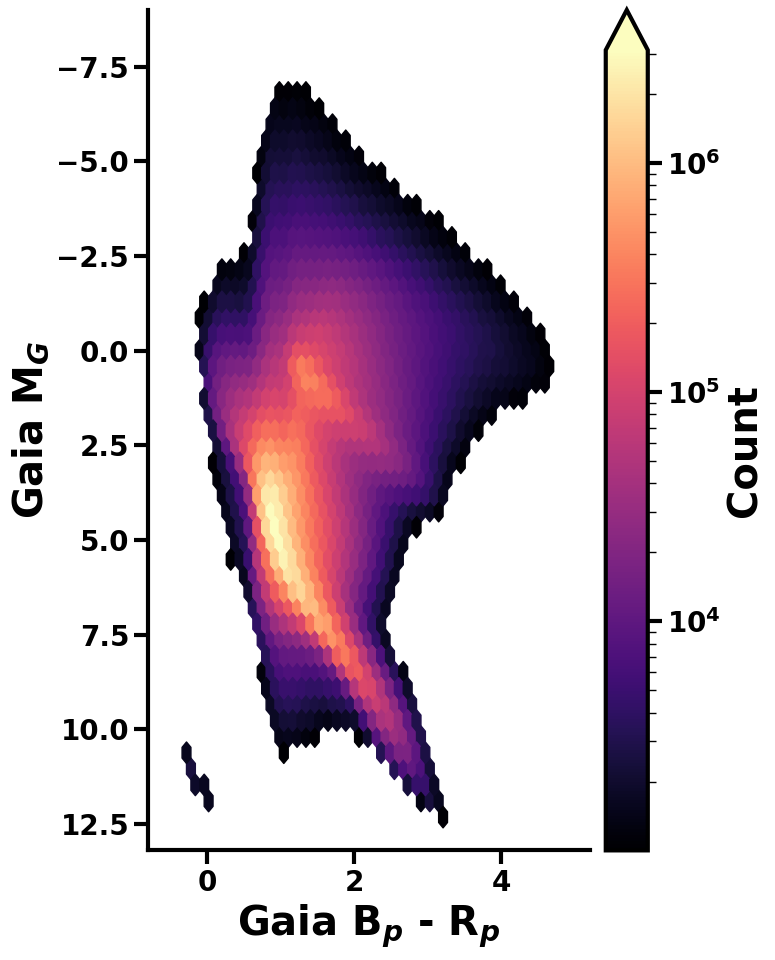

In [9]:
fig, axs = plt.subplots(1, 1, figsize=(8, 10))
axs.set(xlim=(-0.8, 5.2), ylim=(13.2, -9), xlabel='Gaia B$_p$ - R$_p$', ylabel='Gaia M$_G$')
im1 = axs.hexbin('bp-rp', 'abs_g_mag', data=gaiaids, mincnt=1000, bins='log', cmap='magma', rasterized=True)
fig.colorbar(im1, pad=0.03, label='Count', extend='max')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
fig.tight_layout()
plt.savefig('gaia_hr.pdf', dpi=300)